In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from pathlib import Path

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv(r"C:\Users\Hamza Computerz\Downloads\ecommerce_customer_behavior_dataset_v2.csv")

In [3]:
print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (17049, 18)


In [4]:
df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17049 entries, 0 to 17048
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  17049 non-null  object 
 1   Customer_ID               17049 non-null  object 
 2   Date                      17049 non-null  object 
 3   Age                       17049 non-null  int64  
 4   Gender                    17049 non-null  object 
 5   City                      17049 non-null  object 
 6   Product_Category          17049 non-null  object 
 7   Unit_Price                17049 non-null  float64
 8   Quantity                  17049 non-null  int64  
 9   Discount_Amount           17049 non-null  float64
 10  Total_Amount              17049 non-null  float64
 11  Payment_Method            17049 non-null  object 
 12  Device_Type               17049 non-null  object 
 13  Session_Duration_Minutes  17049 non-null  int64  
 14  Pages_

In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 17049
Columns: 18


In [7]:
df.isnull().sum()

Order_ID                    0
Customer_ID                 0
Date                        0
Age                         0
Gender                      0
City                        0
Product_Category            0
Unit_Price                  0
Quantity                    0
Discount_Amount             0
Total_Amount                0
Payment_Method              0
Device_Type                 0
Session_Duration_Minutes    0
Pages_Viewed                0
Is_Returning_Customer       0
Delivery_Time_Days          0
Customer_Rating             0
dtype: int64

In [8]:
print("Duplicate rows",df.duplicated().sum())

Duplicate rows 0


In [9]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order_ID,17049,17049,ORD_005000-4,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,17049,5000,CUST_02860,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,17049,450,2023-07-29,59,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,17049.0,NaN,NaN,NaN,34.945745,11.046855,18.0,26.0,35.0,42.0,75.0
Gender,17049,3,Female,8613,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,17049,10,Istanbul,4402,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Category,17049,8,Sports,2248,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Unit_Price,17049.0,NaN,NaN,NaN,447.901689,722.319705,5.05,73.26,174.68,494.57,7900.01
Quantity,17049.0,NaN,NaN,NaN,3.011379,1.417027,1.0,2.0,3.0,4.0,5.0
Discount_Amount,17049.0,NaN,NaN,NaN,69.788135,240.704662,0.0,0.0,0.0,32.71,6538.29


In [10]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [11]:
print("Invalid dates:", df["Date"].isna().sum())

Invalid dates: 0


In [12]:
numeric_cols = [
    "Unit_Price",
    "Quantity",
    "Discount_Amount",
    "Total_Amount",
    "Session_Duration_Minutes",
    "Pages_Viewed",
    "Delivery_Time_Days",
    "Customer_Rating"
]

In [13]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Unit_Price,17049.0,447.901689,722.319705,5.05,73.26,174.68,494.57,7900.01
Quantity,17049.0,3.011379,1.417027,1.00,2.00,3.00,4.00,5.00
Discount_Amount,17049.0,69.788135,240.704662,0.00,0.00,0.00,32.71,6538.29
Total_Amount,17049.0,1277.438711,2358.436375,6.21,172.97,455.85,1267.75,37852.05
Session_Duration_Minutes,17049.0,14.535633,2.925524,4.00,13.00,15.00,17.00,26.00
Pages_Viewed,17049.0,9.003109,2.259954,1.00,7.00,9.00,11.00,18.00
Delivery_Time_Days,17049.0,6.503607,3.488787,1.00,4.00,6.00,8.00,25.00
Customer_Rating,17049.0,3.899408,1.128803,1.00,3.00,4.00,5.00,5.00


In [14]:
df = df.drop_duplicates().copy()

In [15]:
print(df.isnull().sum())

Order_ID                    0
Customer_ID                 0
Date                        0
Age                         0
Gender                      0
City                        0
Product_Category            0
Unit_Price                  0
Quantity                    0
Discount_Amount             0
Total_Amount                0
Payment_Method              0
Device_Type                 0
Session_Duration_Minutes    0
Pages_Viewed                0
Is_Returning_Customer       0
Delivery_Time_Days          0
Customer_Rating             0
dtype: int64


In [16]:
total_revenue = df["Total_Amount"].sum()
total_orders = df["Order_ID"].nunique()
total_customers = df["Customer_ID"].nunique()
total_units = df["Quantity"].sum()
average_order_value = df["Total_Amount"].mean()

print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Units Sold: {total_units:,}")
print(f"Average Order Value: {average_order_value:,.2f}")

Total Revenue: 21,779,052.59
Total Orders: 17,049
Total Customers: 5,000
Total Units Sold: 51,341
Average Order Value: 1,277.44


In [17]:
monthly_sales = (
    df.set_index("Date")
      .resample("M")["Total_Amount"]
      .sum()
)

C:\Users\Hamza Computerz\AppData\Local\Temp\ipykernel_9588\1261817692.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["Total_Amount"]


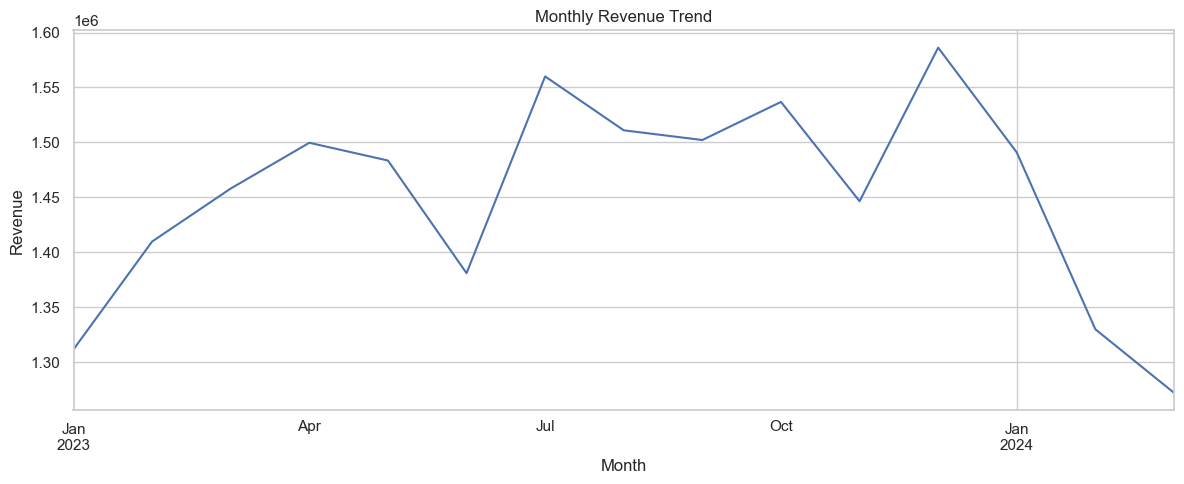

In [18]:
plt.figure(figsize=(12, 5))
monthly_sales.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

In [19]:
category_sales = (
    df.groupby("Product_Category")["Total_Amount"]
      .sum()
      .sort_values(ascending=False)
)

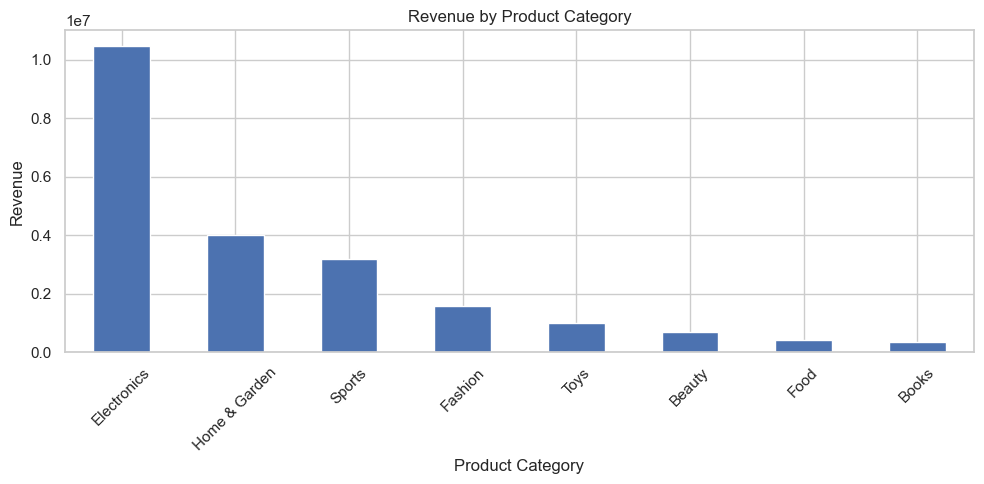

In [20]:
plt.figure(figsize=(10, 5))
category_sales.plot(kind="bar")
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
returning_sales = (
    df.groupby("Is_Returning_Customer")["Total_Amount"]
      .sum()
)

In [22]:
returning_sales

Is_Returning_Customer
False     2588332.13
True     19190720.46
Name: Total_Amount, dtype: float64

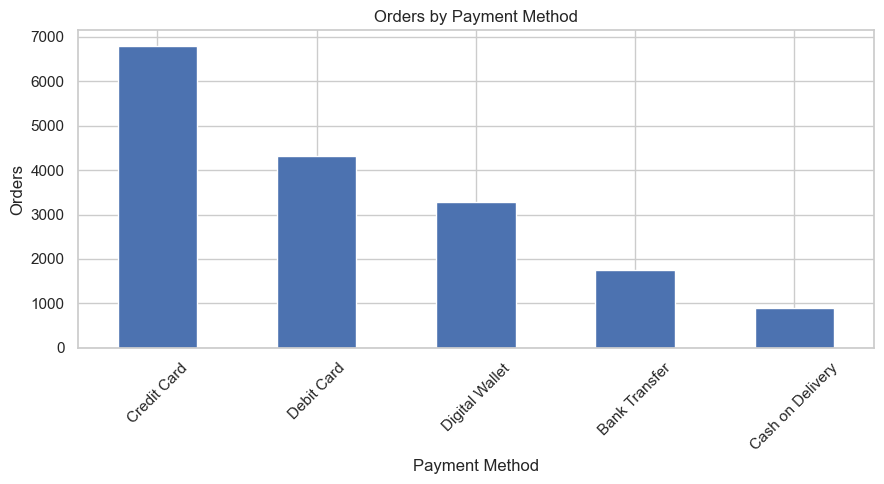

In [23]:
payment_counts = df["Payment_Method"].value_counts()

plt.figure(figsize=(9, 5))
payment_counts.plot(kind="bar")
plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

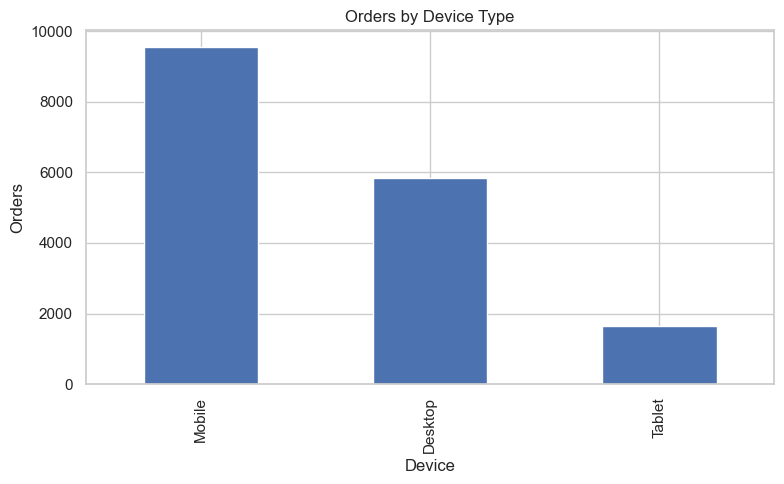

In [24]:
device_counts = df["Device_Type"].value_counts()

plt.figure(figsize=(8, 5))
device_counts.plot(kind="bar")
plt.title("Orders by Device Type")
plt.xlabel("Device")
plt.ylabel("Orders")
plt.tight_layout()
plt.show()

In [25]:
snapshot_date = df["Date"].max() + pd.Timedelta(days=1)

print("Snapshot date:", snapshot_date)

Snapshot date: 2024-03-26 00:00:00


In [26]:
rfm = (
    df.groupby("Customer_ID")
      .agg(
          Recency=("Date", lambda x: (snapshot_date - x.max()).days),
          Frequency=("Order_ID", "nunique"),
          Monetary=("Total_Amount", "sum")
      )
      .reset_index())

In [27]:
rfm.head()

,Customer_ID,Recency,Frequency,Monetary
0,CUST_00001,112,3,2199.63
1,CUST_00002,284,2,809.90
2,CUST_00003,83,2,3030.81
3,CUST_00004,42,1,383.22
4,CUST_00005,279,3,2422.73


In [28]:
rfm[["Recency", "Frequency", "Monetary"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,5000.0,125.716400,108.050972,1.00,39.00,94.000,185.0000,450.00
Frequency,5000.0,3.409800,2.181746,1.00,2.00,3.000,5.0000,10.00
Monetary,5000.0,4355.810518,5274.546636,14.28,889.41,2493.925,5796.2975,50628.15


In [29]:
print("Negative Recency:", (rfm["Recency"] < 0).sum())
print("Negative Frequency:", (rfm["Frequency"] < 0).sum())
print("Negative Monetary:", (rfm["Monetary"] < 0).sum())

Negative Recency: 0
Negative Frequency: 0
Negative Monetary: 0


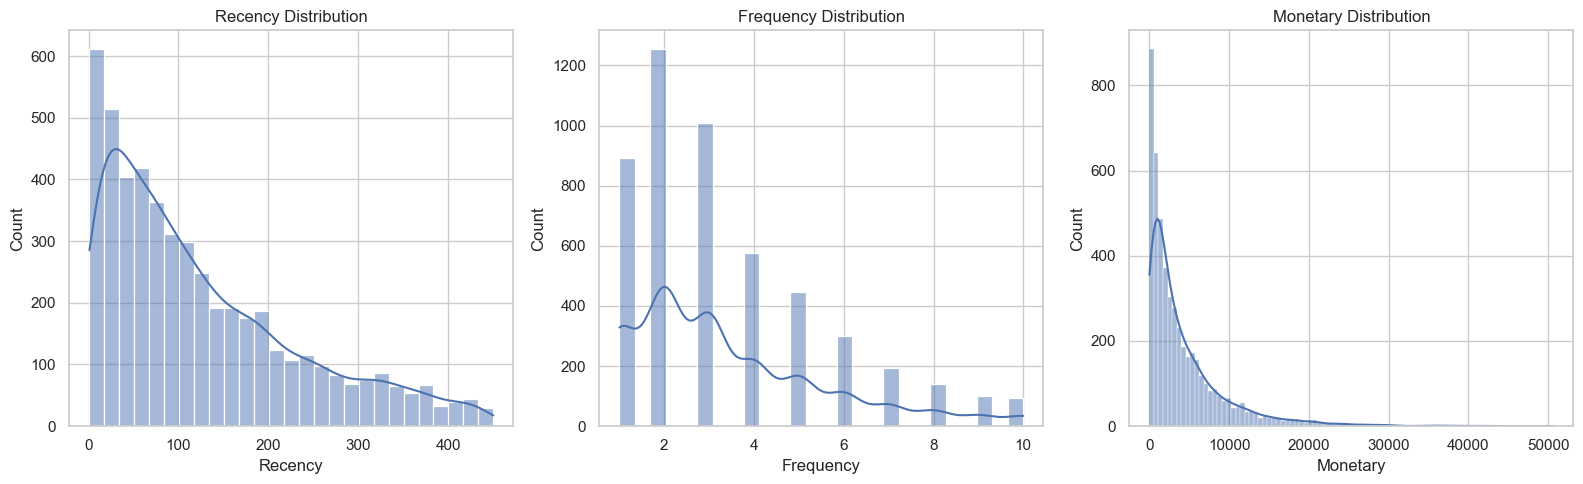

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.histplot(rfm["Recency"], kde=True, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(rfm["Frequency"], kde=True, ax=axes[1])
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm["Monetary"], kde=True, ax=axes[2])
axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

In [31]:
rfm_model = rfm[["Recency", "Frequency", "Monetary"]].copy()

rfm_log = np.log1p(rfm_model)

rfm_log.head()

,Recency,Frequency,Monetary
0,4.727388,1.386294,7.696499
1,5.652489,1.098612,6.698145
2,4.430817,1.098612,8.016915
3,3.761200,0.693147,5.951215
4,5.634790,1.386294,7.793063


In [32]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

print("Scaled RFM shape:", rfm_scaled.shape)

Scaled RFM shape: (5000, 3)


In [33]:
inertia = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(rfm_scaled)
    inertia.append(model.inertia_)


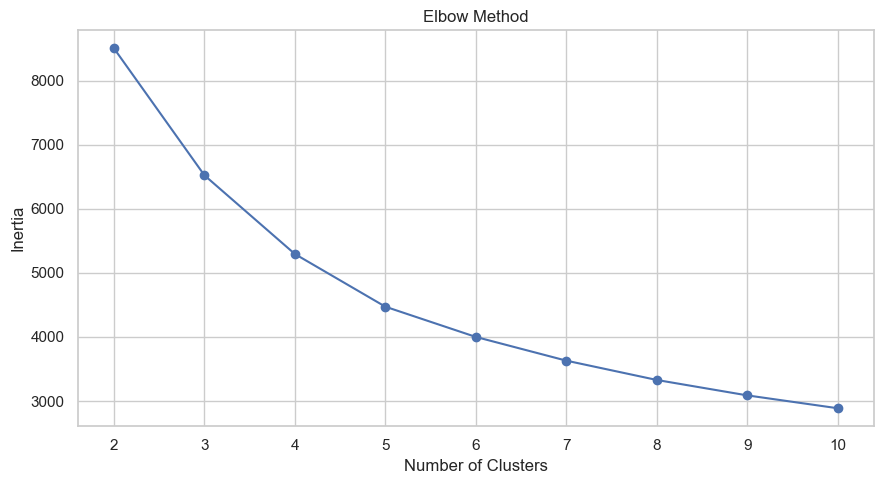

In [34]:
plt.figure(figsize=(9, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()

In [ ]:
silhouette_scores = {}

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)

    silhouette_scores[k] = score

print(silhouette_scores)

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(
    list(silhouette_scores.keys()),
    list(silhouette_scores.values()),
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()


In [ ]:
best_k = max(silhouette_scores, key=silhouette_scores.get)

print("Best K based on silhouette score:", best_k)
print("Best silhouette score:", silhouette_scores[best_k])

In [ ]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [39]:
rfm.head()

,Customer_ID,Recency,Frequency,Monetary,Cluster
0,CUST_00001,112,3,2199.63,1
1,CUST_00002,284,2,809.90,1
2,CUST_00003,83,2,3030.81,1
3,CUST_00004,42,1,383.22,1
4,CUST_00005,279,3,2422.73,1


In [40]:
cluster_profile = (
    rfm.groupby("Cluster")
       .agg(
           Customers=("Customer_ID", "count"),
           Avg_Recency=("Recency", "mean"),
           Avg_Frequency=("Frequency", "mean"),
           Avg_Monetary=("Monetary", "mean")
       )
       .round(2)
)

cluster_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,2509,65.37,4.93,7089.71
1,2491,186.50,1.88,1602.15


In [41]:
cluster_profile["Monetary_Rank"] = (
    cluster_profile["Avg_Monetary"]
    .rank(ascending=False)
)

cluster_profile["Frequency_Rank"] = (
    cluster_profile["Avg_Frequency"]
    .rank(ascending=False)
)

cluster_profile["Recency_Rank"] = (
    cluster_profile["Avg_Recency"]
    .rank(ascending=True)
)


In [42]:
cluster_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Monetary_Rank,Frequency_Rank,Recency_Rank
Cluster,,,,,,,
0,2509,65.37,4.93,7089.71,1.0,1.0,1.0
1,2491,186.50,1.88,1602.15,2.0,2.0,2.0


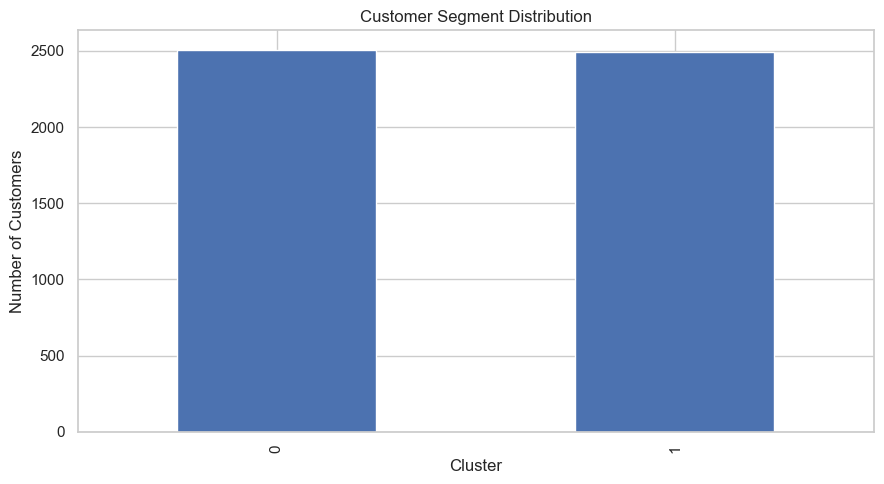

In [43]:
segment_counts = rfm["Cluster"].value_counts().sort_index()

plt.figure(figsize=(9, 5))
segment_counts.plot(kind="bar")
plt.title("Customer Segment Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

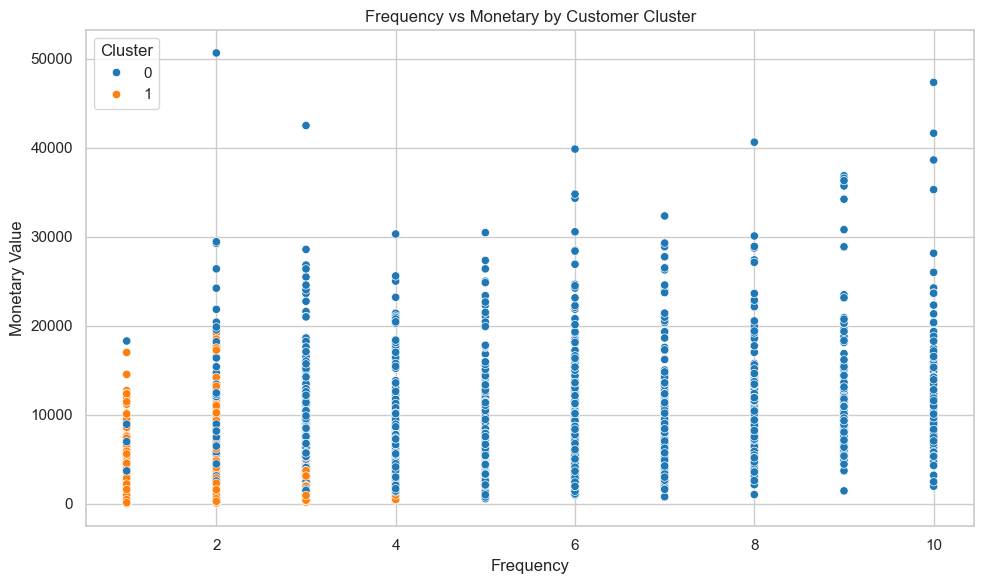

In [44]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="tab10"
)

plt.title("Frequency vs Monetary by Customer Cluster")
plt.xlabel("Frequency")
plt.ylabel("Monetary Value")
plt.tight_layout()
plt.show()

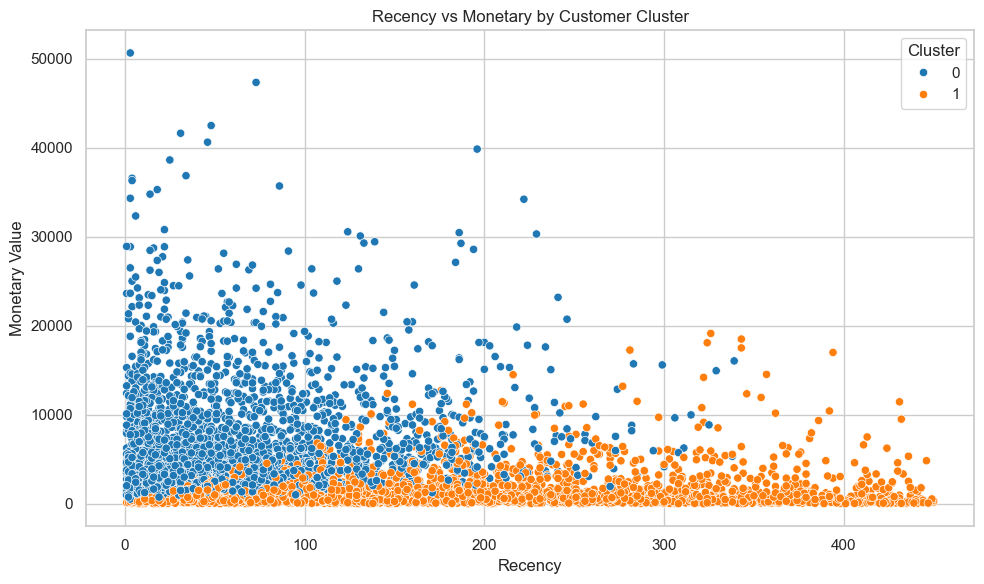

In [45]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="tab10"
)

plt.title("Recency vs Monetary by Customer Cluster")
plt.xlabel("Recency")
plt.ylabel("Monetary Value")
plt.tight_layout()
plt.show()

In [46]:
df_segmented = df.merge(
    rfm[["Customer_ID", "Cluster"]],
    on="Customer_ID",
    how="left"
)

In [47]:
df_segmented.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating,Cluster
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4,1
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2,1
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4,1
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4,1
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4,1


In [48]:
age_segment = (
    df_segmented.groupby("Cluster")["Age"]
    .mean()
    .round(2)
)

In [49]:
age_segment

Cluster
0    34.83
1    35.25
Name: Age, dtype: float64

In [50]:
gender_segment = pd.crosstab(
    df_segmented["Cluster"],
    df_segmented["Gender"],
    normalize="index"
) * 100

gender_segment.round(2)

Gender,Female,Male,Other
Cluster,,,
0,50.75,47.67,1.58
1,49.90,48.71,1.39


In [51]:
device_segment = pd.crosstab(
    df_segmented["Cluster"],
    df_segmented["Device_Type"],
    normalize="index"
) * 100

device_segment.round(2)

Device_Type,Desktop,Mobile,Tablet
Cluster,,,
0,34.56,55.75,9.69
1,33.55,56.57,9.89


In [52]:
payment_segment = pd.crosstab(
    df_segmented["Cluster"],
    df_segmented["Payment_Method"],
    normalize="index"
) * 100

payment_segment.round(2)

Payment_Method,Bank Transfer,Cash on Delivery,Credit Card,Debit Card,Digital Wallet
Cluster,,,,,
0,10.33,5.24,39.75,25.64,19.04
1,10.36,5.12,40.27,24.56,19.69


In [53]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

df.to_csv(
    output_dir / "cleaned_customer_data.csv",
    index=False
)

rfm.to_csv(
    output_dir / "customer_rfm.csv",
    index=False
)

df_segmented.to_csv(
    output_dir / "customer_segments.csv",
    index=False
)

cluster_profile.to_csv(
    output_dir / "cluster_profile.csv"
)

In [54]:
print("Files exported successfully.")

Files exported successfully.


In [55]:
print("Final transaction shape:", df.shape)
print("Final customer count:", rfm["Customer_ID"].nunique())
print("Clusters:", rfm["Cluster"].nunique())
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Final transaction shape: (17049, 18)
Final customer count: 5000
Clusters: 2
Missing values: 0
Duplicate rows: 0


In [56]:
assert df["Customer_ID"].notna().all()
assert df["Date"].notna().all()
assert rfm["Recency"].ge(0).all()
assert rfm["Frequency"].ge(1).all()
assert rfm["Monetary"].ge(0).all()

print("All final validation checks passed.")

All final validation checks passed.


In [61]:

from pathlib import path
print(path("outputs").resolve())

ImportError: cannot import name 'path' from 'pathlib' (C:\ProgramData\anaconda3\Lib\pathlib\__init__.py)